In [ ]:
pip install datasets

In [ ]:
pip install sentence_transformers

## Import library

In [1]:
from collections import Counter, defaultdict
from typing import List, Dict, Literal, Union
import re
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

CACHE_DIR = "./cache"

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("UniverseTBD/arxiv-abstracts-large")

print(ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed'],
        num_rows: 2292057
    })
})


## Discover data

In [3]:
print(ds.shape)

{'train': (2292057, 14)}


In [ ]:
print(ds)

In [ ]:
for i in range(3):
    print(f"Example {i+1}:")
    print(ds["train"][i]["abstract"])
    print(ds["train"][i]["categories"])
    print("---" * 20)

In [4]:
df = ds["train"].to_pandas()

print(df)

                       id           submitter  \
0               0704.0001      Pavel Nadolsky   
1               0704.0002        Louis Theran   
2               0704.0003         Hongjun Pan   
3               0704.0004        David Callan   
4               0704.0005  Alberto Torchinsky   
...                   ...                 ...   
2292052  supr-con/9608008     Ruslan Prozorov   
2292053  supr-con/9609001  Durga P. Choudhury   
2292054  supr-con/9609002  Durga P. Choudhury   
2292055  supr-con/9609003   Hasegawa Yasumasa   
2292056  supr-con/9609004    Masanori Ichioka   

                                                   authors  \
0        C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...   
1                          Ileana Streinu and Louis Theran   
2                                              Hongjun Pan   
3                                             David Callan   
4                 Wael Abu-Shammala and Alberto Torchinsky   
...                                    

In [ ]:
print(df.info())

In [ ]:
print(df.shape)

In [ ]:
print(df.info())

## Split category

Do bài chỉ cần chia primary categories nên chỉ cần split phần đầu tiên của categories làm label

<primary_category.subject> <side_category.subject> <...>
=>  <primary_category>, <side_category>

Ví dụ:
physics.acc-ph hep-ex quant-ph
=> physics, hep-ex

Sau đó lấy 5 category: [‘astro-ph’, ‘cond-mat’, ‘cs’, ‘math’, ‘physics’] để train


In [5]:
all_categories = set(df.categories)
set_feature_names = set()
print(len(all_categories))
print(list(all_categories)[:5])


77849
['gr-qc hep-ph nucl-th quant-ph', 'stat.ML cs.DS cs.LG stat.ME', 'cond-mat.stat-mech math.AP', 'q-bio.MN cond-mat.other', 'physics.ins-det cs.DB cs.DC hep-ex']


In [6]:
for category in all_categories:
    parts = category.split(' ')
    #print(parts)
    for part in parts:
        label = part.split('.')[0]
        #print(label)
        set_feature_names.add(label)

feature_names = sorted(set_feature_names)
print(len(feature_names))
print(feature_names)

38
['acc-phys', 'adap-org', 'alg-geom', 'ao-sci', 'astro-ph', 'atom-ph', 'bayes-an', 'chao-dyn', 'chem-ph', 'cmp-lg', 'comp-gas', 'cond-mat', 'cs', 'dg-ga', 'econ', 'eess', 'funct-an', 'gr-qc', 'hep-ex', 'hep-lat', 'hep-ph', 'hep-th', 'math', 'math-ph', 'mtrl-th', 'nlin', 'nucl-ex', 'nucl-th', 'patt-sol', 'physics', 'plasm-ph', 'q-alg', 'q-bio', 'q-fin', 'quant-ph', 'solv-int', 'stat', 'supr-con']


In [7]:
samples = []

filter_feature_names = ['astro-ph', 'cond-mat', 'cs', 'math', 'physics']

for s in ds['train']:
    if (len(s['categories'].split(' ')) != 1):
        continue
    
    cur_category = s['categories'].strip().split('.')[0]
    if (cur_category not in filter_feature_names):
        continue
    samples.append(s)
    
    if (len(samples) >= 1000):
        break
print(len(samples))
for i in range(5):
    print(samples[i])


1000
{'id': '0704.0003', 'submitter': 'Hongjun Pan', 'authors': 'Hongjun Pan', 'title': 'The evolution of the Earth-Moon system based on the dark matter field\n  fluid model', 'comments': '23 pages, 3 figures', 'journal-ref': None, 'doi': None, 'report-no': None, 'categories': 'physics.gen-ph', 'license': None, 'abstract': "  The evolution of Earth-Moon system is described by the dark matter field\nfluid model proposed in the Meeting of Division of Particle and Field 2004,\nAmerican Physical Society. The current behavior of the Earth-Moon system agrees\nwith this model very well and the general pattern of the evolution of the\nMoon-Earth system described by this model agrees with geological and fossil\nevidence. The closest distance of the Moon to Earth was about 259000 km at 4.5\nbillion years ago, which is far beyond the Roche's limit. The result suggests\nthat the tidal friction may not be the primary cause for the evolution of the\nEarth-Moon system. The average dark matter field f

In [8]:
preprocessed_samples = []
for s in samples:
    abstract = s['abstract']

    # Remove \n characters in the middle and leading/trailing spaces
    abstract = abstract.strip().replace("\n", " ")

    # Remove special characters
    abstract = re.sub(r'[^\w\s]', '', abstract)
    # Remove digits
    abstract = re.sub(r'\d+', '', abstract)
    # Remove extra spaces
    abstract = re.sub(r'\s+', ' ', abstract).strip()
    # Convert to lower case
    abstract = abstract.lower()

    # for the label, we only keep the first part
    parts = s['categories'].split(' ')
    category = parts[0].split('.')[0]

    preprocessed_samples.append({
    "abstract": abstract,
    "category": category})

for i in range(5):
    print(preprocessed_samples[i])

{'abstract': 'the evolution of earthmoon system is described by the dark matter field fluid model proposed in the meeting of division of particle and field american physical society the current behavior of the earthmoon system agrees with this model very well and the general pattern of the evolution of the moonearth system described by this model agrees with geological and fossil evidence the closest distance of the moon to earth was about km at billion years ago which is far beyond the roches limit the result suggests that the tidal friction may not be the primary cause for the evolution of the earthmoon system the average dark matter field fluid constant derived from earthmoon system data is x sm this model predicts that the marss rotation is also slowing with the angular acceleration rate about x rad s', 'category': 'physics'}
{'abstract': 'we show that a determinant of stirling cycle numbers counts unlabeled acyclic singlesource automata the proof involves a bijection from these au

## encode unique category

In [9]:
label_to_id = {label: i for i, label in enumerate(feature_names)}
id_to_label = {i: label for i, label in enumerate(feature_names)}

print("Label to ID mapping:")
for label, id_ in label_to_id.items():
    print(f"{label} --> {id_}")

Label to ID mapping:
acc-phys --> 0
adap-org --> 1
alg-geom --> 2
ao-sci --> 3
astro-ph --> 4
atom-ph --> 5
bayes-an --> 6
chao-dyn --> 7
chem-ph --> 8
cmp-lg --> 9
comp-gas --> 10
cond-mat --> 11
cs --> 12
dg-ga --> 13
econ --> 14
eess --> 15
funct-an --> 16
gr-qc --> 17
hep-ex --> 18
hep-lat --> 19
hep-ph --> 20
hep-th --> 21
math --> 22
math-ph --> 23
mtrl-th --> 24
nlin --> 25
nucl-ex --> 26
nucl-th --> 27
patt-sol --> 28
physics --> 29
plasm-ph --> 30
q-alg --> 31
q-bio --> 32
q-fin --> 33
quant-ph --> 34
solv-int --> 35
stat --> 36
supr-con --> 37


## split train data 80/20

In [10]:
X = [sample['abstract'] for sample in preprocessed_samples]
y = [label_to_id[sample['category']] for sample in preprocessed_samples]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(len(X_train),len( X_test))
print(len(y_train),len( y_test))

print(X_train[0])

800 200
800 200
the polarized neutron scattering in helimagnetic mnsi at low t reveals existence of a partially disordered chiral state at ambient pressure in the magnetic field applied along axis below the first order transition to the nonchiral ferromagnetic state this unexpected phenomenon is explained by the analysis of the spinwave spectrum we demonstrate that the square of the spinwave gap becomes negative under magnetic field applied along and but not along the direction it is a result of competition between the spinwave interaction and cubic anisotropy this negative sign means an instability of the spin wave spectrum for the helix and leads to a destruction of the helical order giving rise to the partially disordered state below the first order ferromagnetic transition


In [11]:
class EmbeddingVectorizer:
    def __init__(
        self,
        model_name: str = 'intfloat/multilingual-e5-base',
        normalize: bool = True
    ):
        self.model = SentenceTransformer(model_name)
        self.normalize = normalize

    def _format_inputs(
    self,
    texts: List[str],
    mode: Literal['query', 'passage']
    ) -> List[str]:
        if mode not in {"query", "passage"}:
            raise ValueError("Mode must be either 'query' or 'passage'")
        return [f"{mode}: {text.strip()}" for text in texts]

    def transform(
        self,
        texts: List[str],
        mode: Literal['query', 'passage'] = 'query'
    ) -> List[List[float]]:
        if mode == 'raw':
            inputs = texts
        else:
            inputs = self._format_inputs(texts, mode)

        embeddings = self.model.encode(inputs, normalize_embeddings= self.normalize)
        return embeddings.tolist()

    def transform_numpy(
    self,
    texts: List[str],
    mode: Literal['query', 'passage'] = 'query'
    ) -> np.ndarray:
        return np.array(self.transform(texts, mode=mode))

In [12]:
# bow
vectorizer_scaler = CountVectorizer()
X_train_vectorizer = vectorizer_scaler.fit_transform(X_train)
X_test_vectorizer = vectorizer_scaler.transform(X_test)

# tf-idf
tf_idf_scaler = TfidfVectorizer()
X_train_tf_idf = tf_idf_scaler.fit_transform(X_train)
X_test_tf_idf = tf_idf_scaler.transform(X_test)

# sentence embedding
sen_scaler = EmbeddingVectorizer()
X_train_sen = sen_scaler.transform_numpy(X_train)
X_test_sen = sen_scaler.transform(X_test)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8265.50it/s]


In [13]:
X_train_bow, X_test_bow = np.array(X_train_vectorizer.toarray()), np.array(X_test_vectorizer.toarray())
X_train_tfidf, X_test_tfidf = np.array(X_train_tf_idf.toarray()), np.array(X_test_tf_idf.toarray())
X_train_embeddings, X_test_embeddings = np.array(X_train_sen), np.array(X_test_tf_idf)

## K-means

In [14]:
def train_and_test_kmeans(X_train, y_train, X_test, y_test, n_clusters: int):
    kmeans = KMeans(n_clusters, random_state=42)
    cluster_ids = kmeans.fit_predict(X_train)
    #print(((cluster_ids.shape)))
    
    cluster_to_label = {}
    for cluster_id in set(cluster_ids):  
        labels_in_cluster = [y_train[i] for i in range(len(y_train)) if cluster_ids[i] == cluster_id]
        most_common_label = Counter(labels_in_cluster).most_common(1)[0][0]
        cluster_to_label[cluster_id] = most_common_label
    
    #   print(f"{key}: {value}")
        
    test_cluster_ids = kmeans.predict(X_test)
    
    y_pred = [cluster_to_label[cluster_id] for cluster_id in test_cluster_ids]
    accuracy = accuracy_score(y_test, y_pred)

    return y_pred, accuracy
km_bow_labels, km_bow_accuracy = train_and_test_kmeans(X_train_vectorizer, y_train, X_test_vectorizer, y_test, n_clusters=len(label_to_id))

In [15]:

km_bow_labels, km_bow_accuracy = train_and_test_kmeans(X_train_vectorizer, y_train, X_test_vectorizer, y_test, n_clusters=len(label_to_id))
km_bow_labels, km_ifids_accuracy = train_and_test_kmeans(X_train_tf_idf, y_train, X_test_tf_idf, y_test, n_clusters=len(label_to_id))
km_bow_labels, km_sen_accuracy = train_and_test_kmeans(X_train_sen, y_train, X_test_sen, y_test, n_clusters=len(label_to_id))


 # Print K-Means results
print("Accuracies for K-Means:")
print(f"Bag of Words: {km_bow_accuracy:.4f}")
print(f"IF-IDS: {km_ifids_accuracy:.4f}")
print(f"Sentences embedding: {km_sen_accuracy:.4f}")

Accuracies for K-Means:
Bag of Words: 0.5550
IF-IDS: 0.5800
Sentences embedding: 0.8650


## KNN

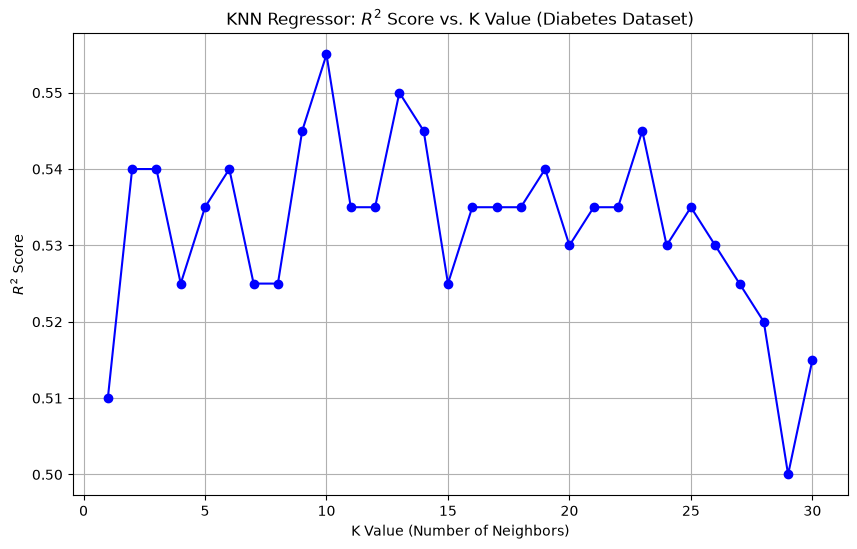

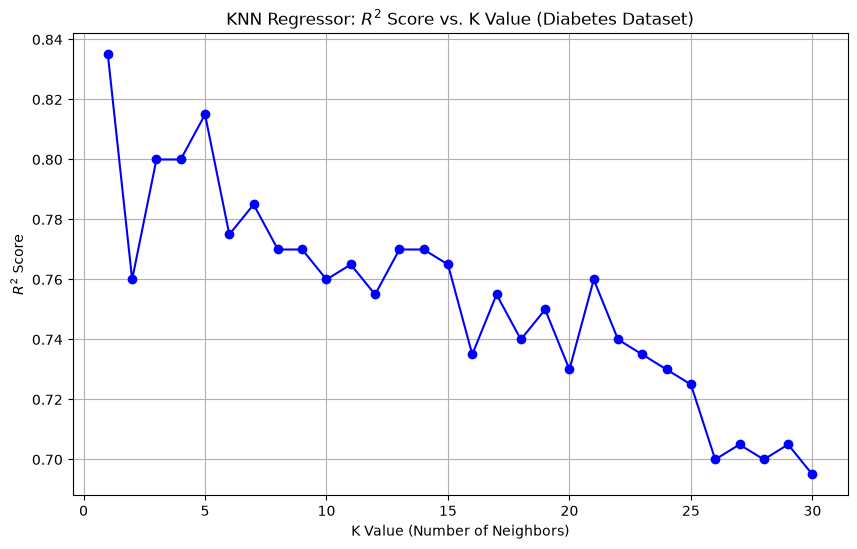

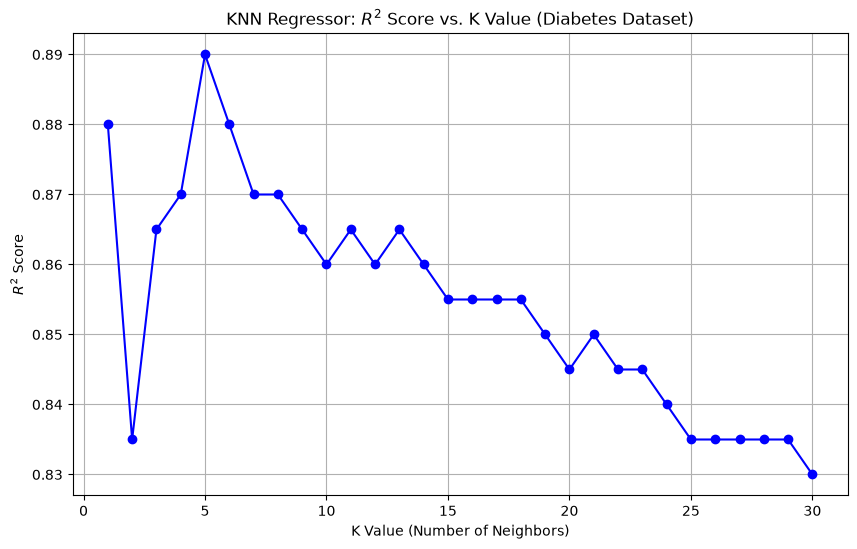

In [27]:
def draw_knn(X_train, y_train, X_test, y_test):
    k_values = [i for i in range(1, 31)]
    scores = []

    for k in k_values:
        knn_classifier = KNeighborsClassifier(k)
        knn_classifier.fit(X_train, y_train)
        y_pred = knn_classifier.predict(X_test)
        score = accuracy_score(y_test, y_pred)
        scores.append(np.mean(score))

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, scores, marker='o', linestyle='-', color='b')
    plt.title('KNN Regressor: $R^2$ Score vs. K Value (Diabetes Dataset)')
    plt.xlabel('K Value (Number of Neighbors)')
    plt.ylabel('$R^2$ Score')
    plt.grid(True)
    plt.show()
    return 

km_bow_accuracy = draw_knn(X_train_vectorizer, y_train, X_test_vectorizer, y_test)
km_ifids_accuracy = draw_knn(X_train_tf_idf, y_train, X_test_tf_idf, y_test)
km_sen_accuracy = draw_knn(X_train_sen, y_train, X_test_sen, y_test)

In [25]:
def train_and_test_knn(X_train, y_train, X_test, y_test):
    k_values = [i for i in range(1, 31)]
    scores = []

    for k in k_values:
        knn_classifier = KNeighborsClassifier(k)
        knn_classifier.fit(X_train, y_train)
        y_pred = knn_classifier.predict(X_test)
        score = accuracy_score(y_test, y_pred)
        scores.append(np.mean(score))
    
    optimal_k = k_values[np.argmax(scores)]
    knn_optimal = KNeighborsClassifier(optimal_k)
    knn_optimal.fit(X_train, y_train)
    pred = knn_optimal.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    return accuracy    
    

In [35]:
knn_bow_accuracy = train_and_test_knn(X_train_vectorizer, y_train, X_test_vectorizer, y_test)
knn_ifids_accuracy = train_and_test_knn(X_train_tf_idf, y_train, X_test_tf_idf, y_test)
knn_sen_accuracy = train_and_test_knn(X_train_sen, y_train, X_test_sen, y_test)

print("Accuracies for KNN:")
print(f"Bag of Words: {knn_bow_accuracy:.4f}")
print(f"IF-IDS: {knn_ifids_accuracy:.4f}")
print(f"Sentences embedding: {knn_sen_accuracy:.4f}")

Accuracies for KNN:
Bag of Words: 0.5550
IF-IDS: 0.8350
Sentences embedding: 0.8900


## Decision tree

In [ ]:
def train_and_test_decision_tree(X_train, y_train, X_test, y_test, md: int):
    classifier = DecisionTreeClassifier(max_depth=md, min_samples_split=10)
    classifier.fit(X_train, y_train)
    
    pred = classifier.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    return accuracy


0.61


In [37]:
dt_bow_accuracy = train_and_test_decision_tree(X_train_vectorizer, y_train, X_test_vectorizer, y_test, md=5)
dt_ifids_accuracy = train_and_test_decision_tree(X_train_tf_idf, y_train, X_test_tf_idf, y_test, md=5)
dt_sen_accuracy = train_and_test_decision_tree(X_train_sen, y_train, X_test_sen, y_test, md=5)

print("Accuracies for Decision tree:")
print(f"Bag of Words: {dt_bow_accuracy:.4f}")
print(f"IF-IDS: {dt_ifids_accuracy:.4f}")
print(f"Sentences embedding: {dt_sen_accuracy:.4f}")


Accuracies for Decision tree:
Bag of Words: 0.6100
IF-IDS: 0.5800
Sentences embedding: 0.7200


## Naive bayes

In [40]:
def train_and_test_naive_bayes(X_train, y_train, X_test, y_test):
    nb = GaussianNB()

    # Naive Bayes requires input to be in dense format
    X_train_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train
    X_test_dense = X_test.toarray() if hasattr(X_test, "toarray") else X_test
    
    nb.fit(X_train_dense, y_train)
    # Predict on the test set
    y_pred = nb.predict(X_test_dense)
    # Calculate accuracy and classification report
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [ ]:
bn_bow_accuracy = train_and_test_naive_bayes(X_train_vectorizer, y_train, X_test_vectorizer, y_test)
bn_ifids_accuracy = train_and_test_naive_bayes(X_train_tf_idf, y_train, X_test_tf_idf, y_test)
bn_sen_accuracy = train_and_test_naive_bayes(X_train_sen, y_train, X_test_sen, y_test)

print("Accuracies for Naive Bayes:")
print(f"Bag of Words: {bn_bow_accuracy:.4f}")
print(f"IF-IDS: {bn_ifids_accuracy:.4f}")
print(f"Sentences embedding: {bn_sen_accuracy}")


Accuracies for Decision tree:
Bag of Words: 0.8500
IF-IDS: 0.8300
Sentences embedding: 0.89
